### CS4423 - Networks
Prof. Götz Pfeiffer<br />
School of Mathematics, Statistics and Applied Mathematics<br />
NUI Galway

**Name**: Cian Mac Liatháin
**ID**: 11476078

# Assignment 4

Provide answers to the problems in the boxes provided.  

The buttons at the top of the page can be used to **create
more boxes if needed**.
The type of box can be changed from `Code` to `Markdown`.
`Code` boxes take (and execute) `python` code.
`Markdown` boxes take (and format nicely) **text input**.
In this way, you can provide answers, ask questions, 
or raise issues, in words.

Some marks will be awarded for
participation and engagement.

When finished, print this notebook into a **pdf** file and submit this to
**blackboard**.

**Deadline** is next Monday at 5pm.

## Setup

This is a `jupyter` notebook.   You can open and interact
with the notebook through one of sites recommended at
its [github](https://github.com/gpfeiffer/cs4423) repository.

Or, you can
install and use `jupyter` as a `python` package on your own laptop or PC.  

The following command loads the `networkx` package into the current session.  
The next command specifies some standard options that can be useful for drawing graphs.  

In order to execute the code in a box,
use the mouse or arrow keys to highlight the box and then press SHIFT-RETURN.

In [162]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
opts = { "with_labels": True, "node_color": 'y' }

Should it ever happen that the notebook becomes unusable, start again with a fresh copy.

## 1.  The Brain-of-a-Worm Network

The [connectome](https://en.wikipedia.org/wiki/Connectome) of an organism is a comprehensive map of
all neural connections between the neurons in the brain.   [C. Elegans](https://en.wikipedia.org/wiki/Caenorhabditis_elegans) is a small worm (1mm long)
whose neural network has been completely determined by the South African biologist [Sydney Brenner](https://en.wikipedia.org/wiki/Sydney_Brenner), who won a Nobel prize for this work in 2002.

An *undirected* connected version of this network on 279 nodes with 2287 connections is available from the 
book's [website](http://www.complex-networks.net/) and is copied here into a single file [`c_elegans_undir.net`](c_elegans_undir.net).  This file is in the [pajek](http://mrvar.fdv.uni-lj.si/pajek/) format,
and can be imported into this notebook with the `nx.read_pajek` command.  This command
constructs a *multigraph*, which can easily be converted into a (simple) graph by applying 
the `nx.Graph` constructor to it.

In [163]:
G = nx.read_pajek("data/c_elegans_undir.net")
G = nx.Graph(G)

**Don't draw this graph!** It is too big to produce a meaningful picture.

Use appropriate `networkx` commands to determine:
* the number of vertices $n$ of `G`,
* the number of edges $m$ of `G`,
* the characteristic path length $L$ of `G`,
* the clustering coefficient $C$ of `G`,
* the number of triangles $n_{\Delta}$ in `G` and
* the transitivity $T = 3 n_{\Delta} / n_{\wedge}$ of `G`.

In [164]:
print("No. of Nodes: ",nx.number_of_nodes(G))
print("No. of Edges: ", nx.number_of_edges(G))
print("Characteristic path length: ", nx.average_shortest_path_length(G))
print("Graph clustering coefficient:", nx.average_clustering(G))
print("Number of triangles: ", sum(nx.triangles(G).values()) )
print("Transitivity: ", nx.transitivity(G))

No. of Nodes:  279
No. of Edges:  2287
Characteristic path length:  2.435625692993992
Graph clustering coefficient: 0.3371339990890197
Number of triangles:  12165
Transitivity:  0.21348097711638356


## 2. Degree Distribution

Any graph $G$ with $n$ nodes and $m$ edges can be compared to a random $G(n, m)$
graph with the same parameters, or to a random $G(n, p)$ graph with parameter $p = m/\binom{n}{2}$.
One attribute of interest is the [**degree distribution**](https://en.wikipedia.org/wiki/Degree_distribution) of $G$.  We know that the degree distribution 
of a random $G(n, p)$ graph is [binomial](https://en.wikipedia.org/wiki/Binomial_distribution).  How does the worm's brain compare to that?

For example, with  $n = 100$ and $m = 292$, one can generate a random graph and
plot its node degrees as a histogram, as follows:

<AxesSubplot:>

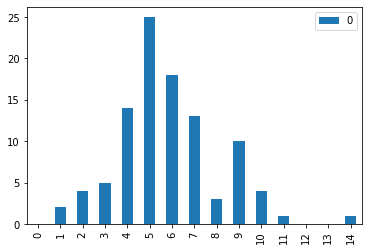

In [165]:
R = nx.gnm_random_graph(100, 292)
hist = nx.degree_histogram(R)
df = pd.DataFrame(hist)
df.plot.bar()

Does that look like a binomial distribution?

* For parameters $n$ and $m$ chosen identical to those of the worm brain graph `G`,
construct a random $G(n, m)$ graph `R`.

* Determine and plot the degree histogram of `R`.

* Determine and plot the degree histogram of `G`.

* In your own words, describe the difference in appearance between the two plots
(in the text cell below, the one that does not have `In []:` written against it).

<AxesSubplot:>

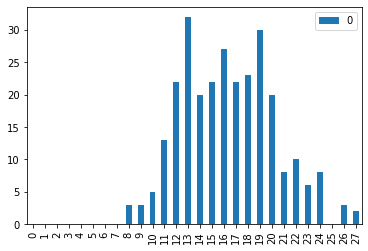

In [166]:
R = nx.gnm_random_graph(279, 2287)
hist = nx.degree_histogram(R)
df = pd.DataFrame(hist)
df.plot.bar()

<AxesSubplot:>

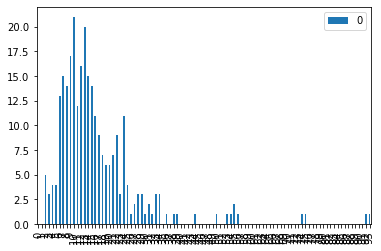

In [167]:
hist = nx.degree_histogram(G)
df = pd.DataFrame(hist)
df.plot.bar()

As expected, we can see that the symmetric degree distribution of the random graph R is binomial.

In contrast, the degree distribution of the worm brain graph shows that there are nodes of extremely high degree which is what would be expected from a power law distribution. 

## 3. Clustering by Degree

Another interesting exercise is studying how the (node) clustering coefficient of a graph $G = (X, E)$ depends on the degree of the nodes.
For each value of $k$, denote by $X_k$ the set of nodes of degree $X_k$.  Then one can define the average clustering at degree $k$ as
$$
C_k = \frac 1 {|X_k|} \sum_{x \in X_K} c(x),
$$
where $c(x)$ is the node clustering coefficient of vertex $x$.

To plot $C_k$ against $k$ will need some preparation.  In order to determine the sets $X_k$,
we can use the map constructed by `G.degree()`, which assigns to each node its degree,
and revert it in such a way that each degree $k$ gets assigned the list of nodes of degree
$k$.  This can be done with a general purpose `python` function that works with
any `python` dictionary `kv`.

In [168]:
def reversed_dict(kv):
    reverse = {}
    for k, v in kv.items():
        reverse.setdefault(v, []).append(k)
    return reverse

For example,  a dictionary of the degrees of a random $G(n, p)$-graph `R` with $n = 16$ and $p = 0.125$
is constructed like so.

In [169]:
R = nx.gnp_random_graph(16, 0.125)
degs = dict(R.degree())
print(degs)

{0: 1, 1: 3, 2: 0, 3: 1, 4: 4, 5: 1, 6: 1, 7: 4, 8: 0, 9: 2, 10: 2, 11: 1, 12: 2, 13: 2, 14: 2, 15: 2}


This dictionary has as *keys* the 16 nodes $0, 1, \dots, 15$,
and for each key as *value* the corresponding node degree, most of the time $1$ or $2$.
We want a dictionary that works in the opposite direction, i.e.. has keys $1$ and $2$
(and whatever else occurs as node degree), and as value for key $2$, say, the list of
all nodes that have degree $2$.  That's what the above function `reversed_dict` constructs:

In [170]:
nodes_by_degree = reversed_dict(degs)
print(nodes_by_degree)

{1: [0, 3, 5, 6, 11], 3: [1], 0: [2, 8], 4: [4, 7], 2: [9, 10, 12, 13, 14, 15]}


Next, we apply the map returned (as `python` dictionary) by the `networkx` command `nx.clustering`
to the node lists in `nodes_by_degree` to obtain a new dictionary `clustering_by_degree`
which contains lists of node clustering coefficients in place of node names, one for each node degree $k$
that occurs in the graph.

In [171]:
clust = nx.clustering(R)
print(clust)

{0: 0, 1: 0, 2: 0, 3: 0, 4: 0.16666666666666666, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 1.0, 13: 0, 14: 1.0, 15: 0}


In [172]:
clustering_by_degree = { d : [clust[x] for x in v] for d, v in nodes_by_degree.items() }
print(clustering_by_degree)

{1: [0, 0, 0, 0, 0], 3: [0], 0: [0, 0], 4: [0.16666666666666666, 0], 2: [0, 0, 1.0, 0, 1.0, 0]}


Finally, we can determine the average value `sum(v)/len(v)` of each list `v` in this dictionary,
and obtain a list of pairs $(k, C_k)$.

In [173]:
avg_clust_degree = [ (d, sum(v)/len(v)) for d, v in clustering_by_degree.items() ]
print(avg_clust_degree)

[(1, 0.0), (3, 0.0), (0, 0.0), (4, 0.08333333333333333), (2, 0.3333333333333333)]


Unsurprisingly, the value of $C_k$ for both $k = 0$ and $k = 1$ is $0$.
Using a `pandas` data frame, the resulting values can be plotted as a scatter plot like this:

<AxesSubplot:xlabel='k', ylabel='C_k'>

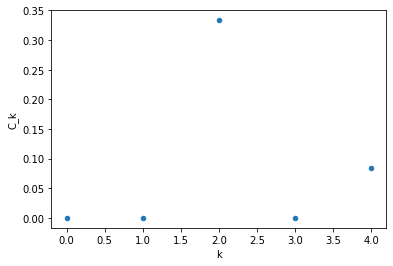

In [174]:
df = pd.DataFrame(avg_clust_degree, columns = ["k", "C_k"] )
df.plot.scatter(x = "k", y = "C_k")

* For a random $G(n, m)$ graph `R` of the same degree and size as the worm brain network `G`,
determine and plot the average degree clustering coefficients $C_k$.

* Use an additional argument `loglog = True` in the plotting command
(i.e., `df.plot.scatter(x = "k", y = "C_k", loglog = True)`) to obtain
a [log-log plot](https://en.wikipedia.org/wiki/Log%E2%80%93log_plot) of the same data.

* Determine and plot the average degree clustering coefficients $C_k$ for the worm brain graph `G`,
again as a log-log plot.

* In your own words, describe the difference, if any, between the two data sets
in the text cell below.

<AxesSubplot:xlabel='k', ylabel='C_k'>

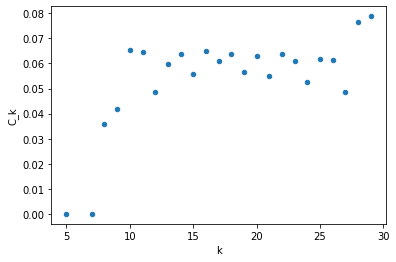

In [175]:
R = nx.gnm_random_graph(279, 2287)
degs = dict(R.degree())
nodes_by_degree = reversed_dict(degs)
clust = nx.clustering(R)
clustering_by_degree = { d : [clust[x] for x in v] for d, v in nodes_by_degree.items() }
avg_clust_degree = [ (d, sum(v)/len(v)) for d, v in clustering_by_degree.items() ]
df = pd.DataFrame(avg_clust_degree, columns = ["k", "C_k"] )
df.plot.scatter(x = "k", y = "C_k")


<AxesSubplot:xlabel='k', ylabel='C_k'>

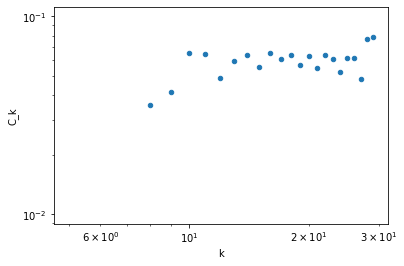

In [176]:
df = pd.DataFrame(avg_clust_degree, columns = ["k", "C_k"] )
df.plot.scatter(x = "k", y = "C_k", loglog=True)

<AxesSubplot:xlabel='k', ylabel='C_k'>

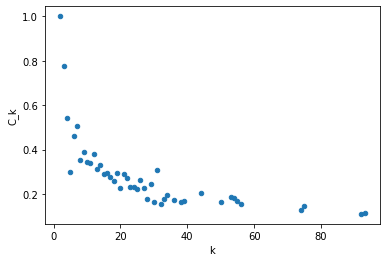

In [177]:
degs = dict(G.degree())
nodes_by_degree = reversed_dict(degs)
clust = nx.clustering(G)
clustering_by_degree = { d : [clust[x] for x in v] for d, v in nodes_by_degree.items() }
avg_clust_degree = [ (d, sum(v)/len(v)) for d, v in clustering_by_degree.items() ]
df = pd.DataFrame(avg_clust_degree, columns = ["k", "C_k"] )
df.plot.scatter(x = "k", y = "C_k")

<AxesSubplot:xlabel='k', ylabel='C_k'>

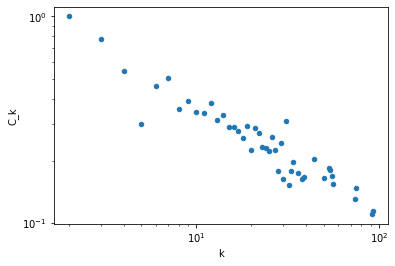

In [178]:
df = pd.DataFrame(avg_clust_degree, columns = ["k", "C_k"] )
df.plot.scatter(x = "k", y = "C_k", loglog=True)

We see no change between the normal scatterplot of the clustering coefficients and loglog plot of R as the degrees of the nodes of of the random graph do not follow a power law distribution.

We can see from the scatterplot of the clustering coefficients of the worm brain graph that it follows a power law distribution with nodes of extremely high degree. By plotting this in a loglog plot we can see that it follows a straight line, which can be used to identify the $\gamma$ value of the power law distribution.

In [179]:
x = np.array(list(df.k))
y= np.array(list(df.C_k))

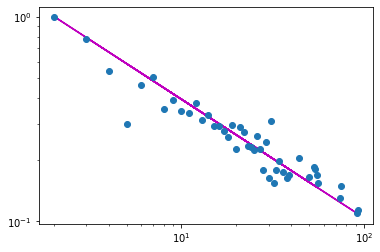

In [185]:
plt.loglog(x, 1.5*10**0/x**0.58, "-m",x, y, 'o')

We can see that the $\gamma$ value here is 0.58

## 4. Small World Models.

Random graphs in the Watts-Strogatz model are obtained from a regular
$(n, d)$-circle graph by randomly rewiring all edges with a given probability $p$.
Such a graph can be generated with the command `nx.watts_strogatz_graph(n, 2*d, p)`
(note that the second argument is actually `2*d`).

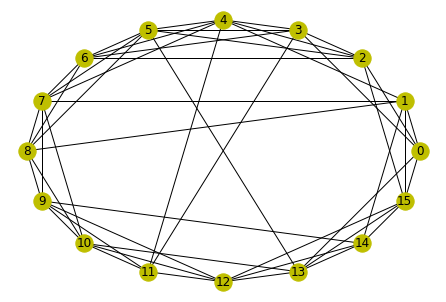

In [181]:
n, d, p = 16, 3, 0.16
G = nx.watts_strogatz_graph(n, 2*d, p)
nx.draw_circular(G, **opts)

Watts-Strogatz random graphs are supposed to be like real world networks in the sense that they
combine relatively *short* characteristic path lengths with relatively *high* clustering coefficients.

*  For values $n = 1000$ and $d = 5$, produce a sequence of 50 (or so) $(n, d, p)$-WS graphs
for different values of $p$ between $0$ and $1$
(including the extreme cases $p = 0$ and $p = 1$).  Compute and compare their
(graph) clustering coefficients and their characteristic path lengths.
(Use smaller values for $n$ if $n = 1000$ turns out to be too demanding on resources.)

* In your own words, in which range of values for $p$, do the generated graphs
indeed have high clustering and short paths?

In [182]:
probabilities = [n/50 for n in range(51)]
n, d = 1000, 5
clusterings = []
paths = []
for p in probabilities:
    G = nx.watts_strogatz_graph(n, 2*d, p)
    clusterings.append(nx.average_clustering(G))
    paths.append(nx.average_shortest_path_length(G))

In [183]:
df = pd.DataFrame({'p': probabilities, 'Clustering Coefficient': clusterings, 'Characteristic Path Length': paths})

In [184]:
df

,p,Clustering Coefficient,Characteristic Path Length
0,0.00,0.666667,50.450450
1,0.02,0.626585,6.751610
2,0.04,0.588807,5.499311
3,0.06,0.562327,5.054713
4,0.08,0.527199,4.677039
5,0.10,0.489421,4.438611
6,0.12,0.466222,4.296394
7,0.14,0.427913,4.126687
8,0.16,0.400989,4.032681
9,0.18,0.377134,3.969283


As the probability increases, we can see an initially fast decrease of the characteristics path length that slows as the probability gets bigger, and a slow decrease of the clustering coefficient.

When 0 < p < 0.14 we see that the characteristic path length is much shorter than the 50.45 found when p = 0, and the clustering coefficient remains relatively high compared to the 0.66 at p = 0. 

When p > 0.14 the clustering coefficient continues to decrease with very little decrease in the chacteristic path length.